#  Jour 2 — Les Fonctions d'Activation

###  Concept Théorique

La **fonction d'activation** est ce qui rend un réseau de neurones puissant. Sans elle, un empilement de neurones ne serait qu'une simple transformation linéaire (une droite). L'activation introduit de la **non-linéarité**, ce qui permet au réseau d'apprendre des relations complexes.

###  Intuition

Pensez aux fonctions d'activation comme des **filtres** :
- **Step** : interrupteur ON/OFF (trop brutal, pas de nuance)
- **Sigmoid** : un variateur de lumière (doux, entre 0 et 1)
- **Tanh** : comme sigmoid mais centré sur zéro (-1 à 1)
- **ReLU** : un clapet anti-retour (laisse passer le positif, bloque le négatif)

###  Formules Essentielles

**Sigmoid :**
$$\sigma(z) = \frac{1}{1 + e^{-z}} \qquad \text{sortie} \in (0, 1)$$

**Dérivée de Sigmoid :**
$$\sigma'(z) = \sigma(z) \cdot (1 - \sigma(z))$$

**Tanh :**
$$\tanh(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}} \qquad \text{sortie} \in (-1, 1)$$

**Dérivée de Tanh :**
$$\tanh'(z) = 1 - \tanh^2(z)$$

**ReLU (Rectified Linear Unit) :**
$$\text{ReLU}(z) = \max(0, z) \qquad \text{sortie} \in [0, +\infty)$$

**Dérivée de ReLU :**
$$\text{ReLU}'(z) = \begin{cases} 1 & \text{si } z > 0 \\ 0 & \text{si } z \le 0 \end{cases}$$

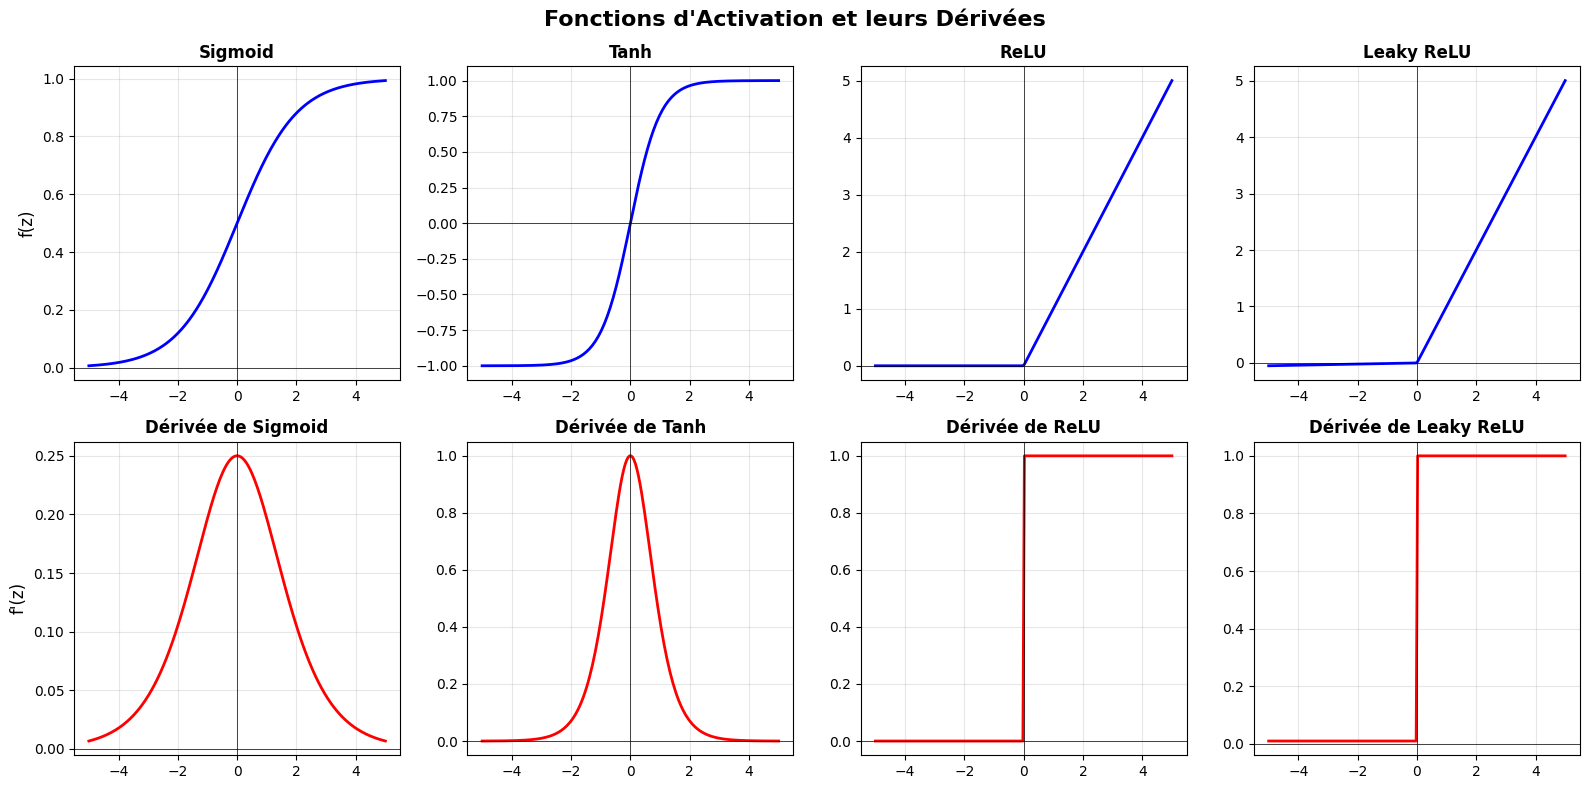

=== Comparaison des activations pour z = [-2, -1, 0, 1, 2] ===

    z |  Sigmoid |     Tanh |     ReLU |  Leaky ReLU
-------------------------------------------------------
   -2 |   0.1192 |  -0.9640 |   0.0000 |     -0.0200
   -1 |   0.2689 |  -0.7616 |   0.0000 |     -0.0100
    0 |   0.5000 |   0.0000 |   0.0000 |      0.0000
    1 |   0.7311 |   0.7616 |   1.0000 |      1.0000
    2 |   0.8808 |   0.9640 |   2.0000 |      2.0000


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# JOUR 2 : Les Fonctions d'Activation
# ============================================================

# --- 1. Sigmoid ---
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

# --- 2. Tanh ---
def tanh(z):
    return np.tanh(z)

def tanh_derivative(z):
    return 1 - np.tanh(z) ** 2

# --- 3. ReLU ---
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

# --- 4. Leaky ReLU ---
def leaky_relu(z, alpha=0.01):
    return np.where(z > 0, z, alpha * z)

def leaky_relu_derivative(z, alpha=0.01):
    return np.where(z > 0, 1, alpha)

# --- Visualisation ---
z = np.linspace(-5, 5, 200)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Fonctions d'Activation et leurs Dérivées", fontsize=16, fontweight='bold')

activations = [
    ("Sigmoid", sigmoid, sigmoid_derivative),
    ("Tanh", tanh, tanh_derivative),
    ("ReLU", relu, relu_derivative),
    ("Leaky ReLU", leaky_relu, leaky_relu_derivative),
]

for i, (name, func, deriv) in enumerate(activations):
    # Fonction
    axes[0, i].plot(z, func(z), 'b-', linewidth=2)
    axes[0, i].set_title(f"{name}", fontweight='bold')
    axes[0, i].axhline(y=0, color='k', linewidth=0.5)
    axes[0, i].axvline(x=0, color='k', linewidth=0.5)
    axes[0, i].grid(True, alpha=0.3)

    # Dérivée
    axes[1, i].plot(z, deriv(z), 'r-', linewidth=2)
    axes[1, i].set_title(f"Dérivée de {name}", fontweight='bold')
    axes[1, i].axhline(y=0, color='k', linewidth=0.5)
    axes[1, i].axvline(x=0, color='k', linewidth=0.5)
    axes[1, i].grid(True, alpha=0.3)

axes[0, 0].set_ylabel("f(z)", fontsize=12)
axes[1, 0].set_ylabel("f'(z)", fontsize=12)

plt.tight_layout()
plt.show()

# --- Comparaison numérique ---
print("=== Comparaison des activations pour z = [-2, -1, 0, 1, 2] ===\n")
test_values = np.array([-2, -1, 0, 1, 2])

print(f"{'z':>5} | {'Sigmoid':>8} | {'Tanh':>8} | {'ReLU':>8} | {'Leaky ReLU':>11}")
print("-" * 55)
for val in test_values:
    print(f"{val:>5} | {sigmoid(val):>8.4f} | {tanh(val):>8.4f} | "
          f"{relu(val):>8.4f} | {leaky_relu(val):>11.4f}")

###  Quand utiliser quelle activation ?

| Activation | Quand l'utiliser | Avantages | Inconvénients |
|---|---|---|---|
| Sigmoid | Couche de sortie (classif. binaire) | Probabilité [0,1] | Vanishing gradient |
| Tanh | Couches cachées (ancien) | Centrée sur 0 | Vanishing gradient |
| ReLU | Couches cachées (défaut) | Rapide, pas de vanishing | Dying neurons |
| Leaky ReLU | Couches cachées | Résout dying ReLU | Hyperparamètre α |